# Standard Scaling (Standardization)

## Introduction

Standard Scaling, also known as **Standardization**, is a feature scaling technique used to transform numerical features so that they have a **mean of 0 and a standard deviation of 1**.

Many machine learning algorithms assume that features are centered around zero and have similar variance. Standardization helps normalize the distribution of features without restricting them to a fixed range.

---

## Why Standard Scaling is Important

- Ensures all features contribute equally to the model  
- Prevents features with large values from dominating  
- Improves convergence speed of optimization algorithms  
- Essential for distance-based and gradient-based models  

---

## Mathematical Formula

Standardization transforms a value \( X \) using the formula:

\[
Z = \frac{X - \mu}{\sigma}
\]

Where:

- \( X \) = original value  
- \( \mu \) = mean of the feature  
- \( \sigma \) = standard deviation  

After transformation:

- Mean ≈ 0  
- Standard deviation ≈ 1  

---

## Example Using Scikit-Learn

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### import Requiremnts 

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

### Load Dataset 

In [3]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df=df[['survived','pclass','parch']]
df

,survived,pclass,parch
0,0,3,0
1,1,1,0
2,1,3,0
3,1,1,0
4,0,3,0
...,...,...,...
886,0,2,0
887,1,1,0
888,0,3,2
889,1,1,0


### train test split 

In [5]:
# convert Matrix and vector
X=df.drop('survived',axis=1)
y=df['survived']
print("Shape of X:",X.shape)
print("Shape of y:",y.shape)

Shape of X: (891, 2)
Shape of y: (891,)


In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
# print Shape
print("shape of X_train:",X_train.shape)
print("shape of X_test:",X_test.shape)
print("shape of y_train:",y_train.shape)
print("shape of y_test:",y_test.shape)

shape of X_train: (712, 2)
shape of X_test: (179, 2)
shape of y_train: (712,)
shape of y_test: (179,)


## Apply Standard scaler

In [9]:
sc=StandardScaler()
sc.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [10]:
sc.mean_

array([2.33005618, 0.37921348])

In [11]:
sc.scale_

array([0.82400502, 0.79111317])

In [12]:
# Check all the data value 
X_train.describe()

,pclass,parch
count,712.000000,712.000000
mean,2.330056,0.379213
std,0.824584,0.791669
min,1.000000,0.000000
25%,2.000000,0.000000
50%,3.000000,0.000000
75%,3.000000,0.000000
max,3.000000,6.000000


In [13]:
# Transform the data in X_train & y_Train data variable
X_train_sc=sc.fit_transform(X_train)
X_test_sc=sc.fit_transform(X_test)

In [14]:
# convert to dataframe
X_train_sc =pd.DataFrame(X_train_sc, columns = ['pclass','parch'])
X_test_sc =pd.DataFrame(X_test_sc, columns = ['pclass','parch'])

In [15]:
X_test_sc.describe()

,pclass,parch
count,1.790000e+02,1.790000e+02
mean,-2.524362e-16,2.480945e-17
std,1.002805e+00,1.002805e+00
min,-1.398170e+00,-4.543156e-01
25%,-1.398170e+00,-4.543156e-01
50%,8.874229e-01,-4.543156e-01
75%,8.874229e-01,-4.543156e-01
max,8.874229e-01,5.354434e+00


In [16]:
X_test_sc

,pclass,parch
0,0.887423,0.707434
1,-0.255373,-0.454316
2,0.887423,-0.454316
3,-0.255373,0.707434
4,0.887423,-0.454316
...,...,...
174,0.887423,-0.454316
175,0.887423,-0.454316
176,0.887423,5.354434
177,-0.255373,-0.454316


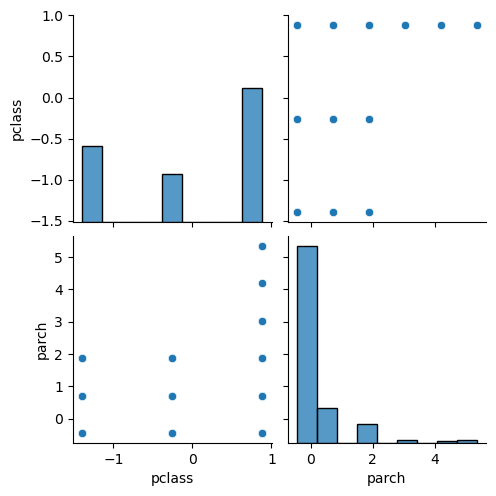

In [50]:
sns.pairplot(X_test_sc)

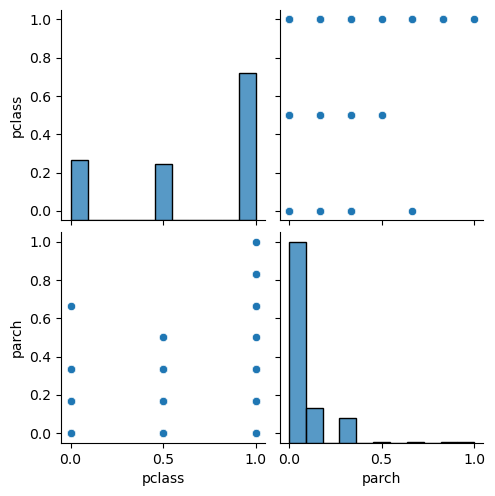

In [51]:
sns.pairplot(X_train_mmc)

In [6]:
df2=sns.load_dataset('iris')
df2.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
df_iris=df2[['sepal_length','sepal_width','petal_length','petal_width']]

In [8]:
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
df_iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64

In [14]:
X=df_iris.drop('petal_length',axis=1)
y=df_iris['petal_length']

In [11]:
# Train and Test the Data is Perfectly predicted or Not
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=50)

In [17]:
X_train.shape

(120, 3)

In [18]:
X_test.shape

(30, 3)

In [25]:
sc=StandardScaler()

In [26]:
sc.fit(X_train)

StandardScaler()

In [28]:
X_train.describe()

,sepal_length,sepal_width,petal_width
count,120.000000,120.000000,120.000000
mean,5.790833,3.061667,1.180833
std,0.825741,0.434864,0.759068
min,4.300000,2.000000,0.100000
25%,5.100000,2.800000,0.300000
50%,5.750000,3.000000,1.300000
75%,6.400000,3.400000,1.800000
max,7.700000,4.400000,2.500000


In [30]:
X_train=sc.fit_transform(X_train)
X_train

array([[ 1.71370359,  0.31944112,  0.81911343],
       [-0.84013026, -1.29700793, -0.10693675],
       [ 0.37598109, -0.60424405,  0.02535614],
       [ 1.10564791,  0.55036241,  1.74516361],
       [-0.84013026,  1.47404758, -1.03298693],
       [-1.44818594,  0.08851983, -1.29757269],
       [-0.71851913, -0.83516534,  0.2899419 ],
       [ 0.25436996, -1.9897718 ,  0.42223478],
       [-0.47529686, -0.14240146,  0.42223478],
       [-0.9617414 ,  0.78128371, -1.29757269],
       [-1.56979708, -1.75885051, -1.16527981],
       [-1.08335253, -1.52792922, -0.23922963],
       [ 0.86242564, -0.14240146,  1.34828496],
       [-1.69140821, -0.37332276, -1.29757269],
       [ 1.59209245, -0.14240146,  1.21599208],
       [-0.84013026,  1.012205  , -1.16527981],
       [-1.69140821,  0.31944112, -1.29757269],
       [-0.11046345,  1.70496888, -1.16527981],
       [ 0.61920337, -1.29700793,  0.95140631],
       [ 0.01114769, -0.60424405,  1.61287073],
       [ 0.98403677, -0.14240146,  0.289

In [31]:
X_train_df=pd.DataFrame(X_train,columns=["sepal_length",'sepal_width','petal_width'])

In [32]:
X_train_df.head()

,sepal_length,sepal_width,petal_width
0,1.713704,0.319441,0.819113
1,-0.840130,-1.297008,-0.106937
2,0.375981,-0.604244,0.025356
3,1.105648,0.550362,1.745164
4,-0.840130,1.474048,-1.032987


In [33]:
X_train_df['sepal_length'].mean()

1.1102230246251566e-17

In [34]:
X_train_df['sepal_length'].std()

1.0041928905068673